# Student information
*   **Student ID:** 20521663
*   **Full name:** Nguyen Dang Bao Ngoc


# Import libraries

In [ ]:
pip install seaborn

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                            precision_recall_fscore_support,
                            f1_score, recall_score,
                            precision_score,
                            confusion_matrix,
                            accuracy_score,
                            ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.stats as stats
import re
import seaborn as sns


# Load processed data

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/[CS116] Lập trình Python cho ML/

/content/drive/.shortcut-targets-by-id/1lEcWUmlO6Ezr-effHzBr4bErLfSGwoym/[CS116] Lập trình Python cho ML


In [ ]:
df = pd.read_csv("./Files/cleaned_credit_score.csv")
X = df.loc[:, df.columns != 'Credit_Score'].to_numpy()
y = df['Credit_Score'].to_numpy()

In [ ]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,credit-builder loan,home equity loan,student loan,payday loan,personal loan,mortgage loan,debt consolidation loan,not specified,No Data,Credit_Score
0,1,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,1,1,0,0,1,0,0,0,0,0
1,2,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,-1.0,...,1,1,0,0,1,0,0,0,0,0
2,3,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,1,1,0,0,1,0,0,0,0,0
3,4,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,5.0,...,1,1,0,0,1,0,0,0,0,0
4,5,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,...,1,1,0,0,1,0,0,0,0,0


# Training model


## Fine tuning

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40)

In [ ]:
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

### Not normalize

In [ ]:
print("X shape: ",X.shape)
print("y shape: ",y.shape)

KNN = KNeighborsClassifier()
params = {'weights' : ['uniform', 'distance'],
          'n_neighbors': range(5, 20, 2),
          'p': [1, 2],
          'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
          }

clf = RandomizedSearchCV(KNN, params, n_iter=50, verbose = 3)
search = clf.fit(X_train, y_train)
search.best_params_

X shape:  (100000, 33)
y shape:  (100000,)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END algorithm=auto, n_neighbors=9, p=2, weights=distance;, score=0.743 total time=   0.7s
[CV 2/5] END algorithm=auto, n_neighbors=9, p=2, weights=distance;, score=0.746 total time=   0.6s
[CV 3/5] END algorithm=auto, n_neighbors=9, p=2, weights=distance;, score=0.741 total time=   0.7s
[CV 4/5] END algorithm=auto, n_neighbors=9, p=2, weights=distance;, score=0.740 total time=   0.6s
[CV 5/5] END algorithm=auto, n_neighbors=9, p=2, weights=distance;, score=0.738 total time=   0.6s
[CV 1/5] END algorithm=auto, n_neighbors=19, p=2, weights=distance;, score=0.734 total time=   0.7s
[CV 2/5] END algorithm=auto, n_neighbors=19, p=2, weights=distance;, score=0.735 total time=   0.6s
[CV 3/5] END algorithm=auto, n_neighbors=19, p=2, weights=distance;, score=0.732 total time=   0.6s
[CV 4/5] END algorithm=auto, n_neighbors=19, p=2, weights=distance;, score=0.729 total time=   0.6s


{'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'algorithm': 'kd_tree'}

### Normalized

In [ ]:
print("X shape: ",X.shape)
print("y shape: ",y.shape)

KNN = KNeighborsClassifier()
params = {'weights' : ['uniform', 'distance'],
          'n_neighbors': range(5, 20, 2),
          'p': [1, 2],
          'algorithm': ['ball_tree', 'kd_tree', 'brute']
          }

clf = RandomizedSearchCV(KNN, params, n_iter=50, verbose = 3)
search = clf.fit(X_train_norm, y_train)
search.best_params_

X shape:  (100000, 33)
y shape:  (100000,)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END algorithm=brute, n_neighbors=19, p=1, weights=distance;, score=0.781 total time=   3.0s
[CV 2/5] END algorithm=brute, n_neighbors=19, p=1, weights=distance;, score=0.781 total time=   3.1s
[CV 3/5] END algorithm=brute, n_neighbors=19, p=1, weights=distance;, score=0.782 total time=   3.0s
[CV 4/5] END algorithm=brute, n_neighbors=19, p=1, weights=distance;, score=0.775 total time=   3.2s
[CV 5/5] END algorithm=brute, n_neighbors=19, p=1, weights=distance;, score=0.780 total time=   3.2s
[CV 1/5] END algorithm=kd_tree, n_neighbors=5, p=2, weights=distance;, score=0.761 total time=  14.5s
[CV 2/5] END algorithm=kd_tree, n_neighbors=5, p=2, weights=distance;, score=0.760 total time=  14.3s
[CV 3/5] END algorithm=kd_tree, n_neighbors=5, p=2, weights=distance;, score=0.755 total time=  14.4s
[CV 4/5] END algorithm=kd_tree, n_neighbors=5, p=2, weights=distance;, score=0.755 t

{'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'algorithm': 'brute'}

## Save RandomSearchCV results

In [ ]:
# convert array into dataframe
cv_results = pd.DataFrame(search.cv_results_)

# save the dataframe as a csv file
cv_results.to_csv("RandomSearchCV_KNN_Normalized_Final.csv")


In [ ]:
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_weights,param_p,param_n_neighbors,param_algorithm,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005191,0.000212,3.096104,0.093282,distance,1,19,brute,"{'weights': 'distance', 'p': 1, 'n_neighbors':...",0.781312,0.781000,0.781563,0.775500,0.779937,0.779863,0.002250,15
1,0.039632,0.002241,14.090171,0.497082,distance,2,5,kd_tree,"{'weights': 'distance', 'p': 2, 'n_neighbors':...",0.761375,0.760188,0.755500,0.754812,0.752687,0.756912,0.003313,19
2,0.004820,0.000265,2.976576,0.047523,uniform,1,5,brute,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.793750,0.791312,0.791188,0.784813,0.791188,0.790450,0.002983,11
3,0.005051,0.000143,0.859093,0.035447,uniform,2,13,brute,"{'weights': 'uniform', 'p': 2, 'n_neighbors': ...",0.706500,0.702500,0.701125,0.698500,0.698750,0.701475,0.002922,46
4,0.004994,0.000065,3.254973,0.063653,uniform,1,17,brute,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.729125,0.728938,0.726875,0.724500,0.727938,0.727475,0.001690,35
5,0.005150,0.000183,3.196277,0.094961,uniform,1,19,brute,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.724625,0.723375,0.722063,0.718875,0.722625,0.722313,0.001921,39
6,0.041040,0.007514,20.014947,0.434365,distance,2,19,kd_tree,"{'weights': 'distance', 'p': 2, 'n_neighbors':...",0.724688,0.719187,0.722625,0.717812,0.721500,0.721162,0.002441,40
7,0.045121,0.002452,22.388997,0.451519,uniform,2,9,ball_tree,"{'weights': 'uniform', 'p': 2, 'n_neighbors': ...",0.717688,0.715688,0.716875,0.712187,0.712125,0.714913,0.002339,43
8,0.004880,0.000387,2.992409,0.114984,uniform,1,7,brute,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.781500,0.781813,0.775500,0.774438,0.777625,0.778175,0.003024,16
9,0.005023,0.000044,3.094707,0.074246,distance,1,13,brute,"{'weights': 'distance', 'p': 1, 'n_neighbors':...",0.795937,0.793750,0.793312,0.789125,0.790562,0.792538,0.002416,9


## Best parameters after tuning

In [ ]:
search.best_params_

{'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'algorithm': 'brute'}

In [ ]:
print(f"Best score after RandomSearchCV: {search.best_score_}")

Best score after RandomSearchCV: 0.8068


# Evaluate

## Not normalize

### Training and testing

In [ ]:
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40)

clf = KNeighborsClassifier(weights = 'distance', p = 1, n_neighbors = 5, algorithm = 'kd_tree')

clf.fit(X_train, y_train)
print("Accuracy test: ", clf.score(X_test, y_test))

X shape:  (100000, 33)
y shape:  (100000,)
Accuracy test:  0.7784


In [ ]:
target_names = ['Good', 'Poor', 'Standard']
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

        Good       0.73      0.72      0.73      3657
        Poor       0.77      0.80      0.79      5694
    Standard       0.80      0.78      0.79     10649

    accuracy                           0.78     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.78      0.78      0.78     20000



### K-Fold

In [ ]:
kf = KFold(n_splits=10, shuffle=True)
acc = []
f1_macro = []
recall_macro = []
precision_macro = []
metrics = []
confusion_matrices = np.zeros((3,3))
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    clf.fit(X[train_index], y[train_index])
    y_pred = clf.predict(X[test_index])
    print(classification_report(y[test_index], y_pred, target_names=target_names))
    metrics.append(precision_recall_fscore_support(y[test_index], y_pred))
    print()
    acc.append(clf.score(X[test_index], y[test_index]))
    f1_macro.append(f1_score(y[test_index], y_pred, average="macro"))
    recall_macro.append(recall_score(y[test_index], y_pred, average="macro"))
    precision_macro.append(precision_score(y[test_index], y_pred, average="macro"))
    confusion_matrices = confusion_matrices + confusion_matrix(y[test_index], y_pred)

print("Mean accuray:", np.mean(acc))

Fold 0:
              precision    recall  f1-score   support

        Good       0.74      0.72      0.73      1759
        Poor       0.77      0.82      0.80      2896
    Standard       0.81      0.79      0.80      5345

    accuracy                           0.79     10000
   macro avg       0.77      0.78      0.77     10000
weighted avg       0.79      0.79      0.79     10000


Fold 1:
              precision    recall  f1-score   support

        Good       0.76      0.72      0.74      1790
        Poor       0.77      0.80      0.79      2888
    Standard       0.80      0.80      0.80      5322

    accuracy                           0.79     10000
   macro avg       0.78      0.77      0.78     10000
weighted avg       0.79      0.79      0.79     10000


Fold 2:
              precision    recall  f1-score   support

        Good       0.74      0.74      0.74      1788
        Poor       0.77      0.81      0.79      2941
    Standard       0.80      0.78      0.79      

#### Evaluation results on K-Fold

In [ ]:
print(f"Average macro F1 : {round(np.mean(f1_macro), 3)}")
print(f"Average macro Recall : {round(np.mean(recall_macro), 3)}")
print(f"Average macro Accuray:", round(np.mean(acc), 3))
print(f"Average macro Precision : {round(np.mean(precision_macro), 3)}")

Average macro F1 : 0.773
Average macro Recall : 0.776
Average macro Accuray: 0.783
Average macro Precision : 0.771


### Visualize result

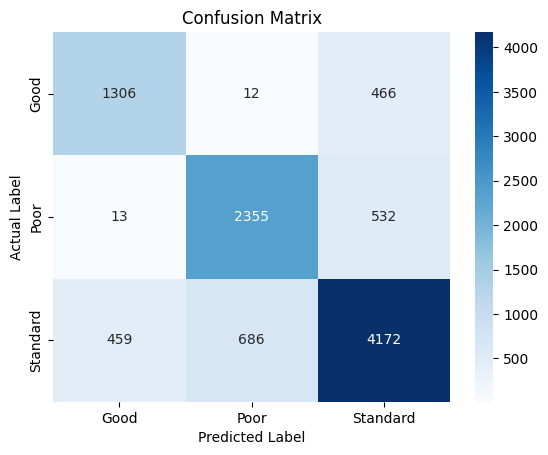

In [ ]:
# Create labels for the confusion matrix
labels = ['Good', 'Poor', 'Standard']

# Create a heatmap using seaborn
sns.heatmap(np.round(confusion_matrices / 10).astype(np.int64), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)

# Set plot title and axes labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Display the plot
plt.show()

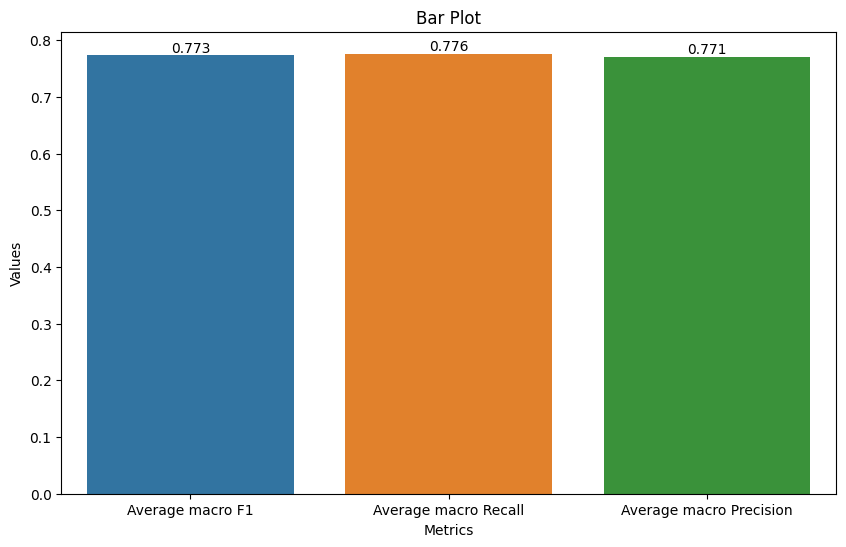

In [ ]:
# Sample data
categories = ['Average macro F1', 'Average macro Recall', 'Average macro Precision']
values = [np.mean(f1_macro), np.mean(recall_macro), np.mean(precision_macro)]

# Set the figure size
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(x=categories, y=values)

# Add numbers on top of the bars
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 3)), ha='center', va='bottom')

# Set plot title and axes labels
plt.title('Bar Plot')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Display the plot
plt.show()

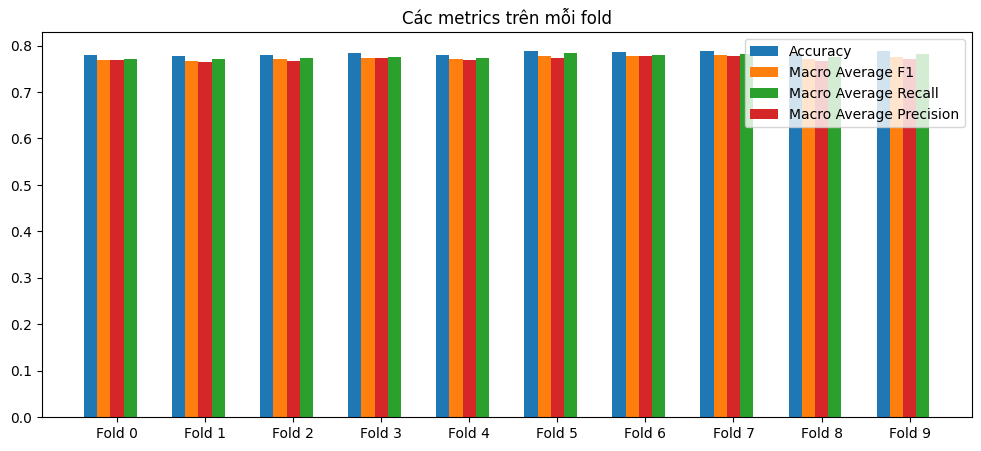

In [ ]:
plt.figure(figsize=(12,5))
X_ticks = ["Fold " + str(i) for i in range(10)]
X_axis = np.arange(len(X_ticks))
plt.bar(X_axis - 0.3, acc, 0.15, label="Accuracy", tick_label=X_ticks)
plt.bar(X_axis - 0.15, f1_macro, 0.15, label="Macro Average F1", tick_label=X_ticks)
plt.bar(X_axis + 0.15, recall_macro, 0.15, label="Macro Average Recall", tick_label=X_ticks)
plt.bar(X_axis, precision_macro, 0.15, label="Macro Average Precision", tick_label=X_ticks)
plt.title("Các metrics trên mỗi fold")
plt.legend()
plt.show()

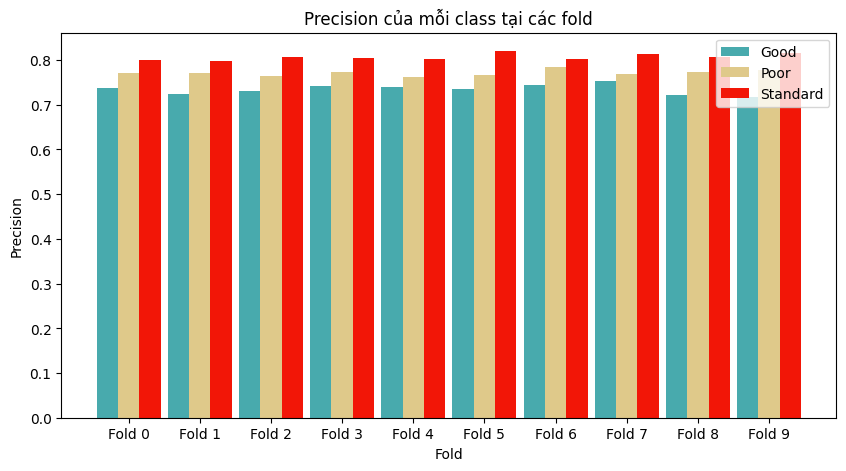

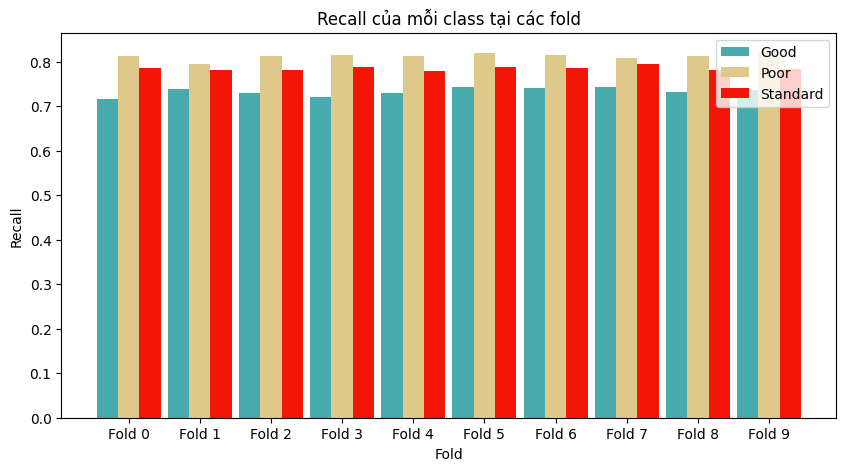

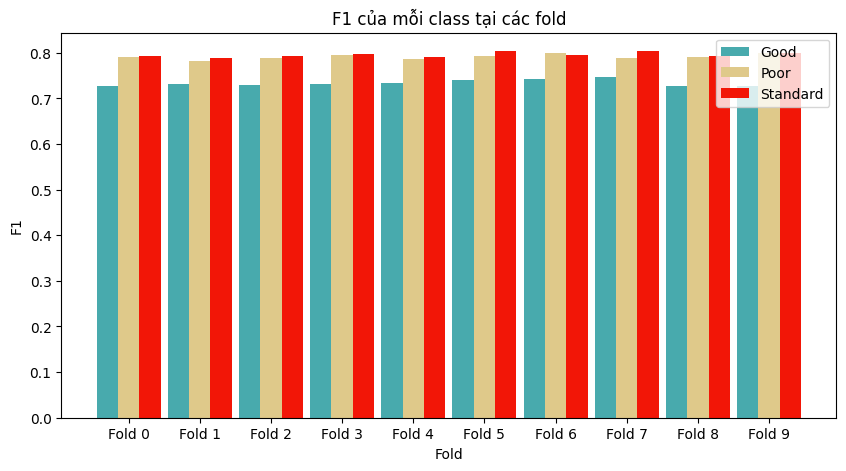

In [ ]:
metrics_dict = {
    "Precision": [],
    "Recall" : [],
    "F1": []
}

for i in range(10):
  metrics_dict["Precision"].append(metrics[i][0])
  metrics_dict["Recall"].append(metrics[i][1])
  metrics_dict["F1"].append(metrics[i][2])

metrics_dict["Precision"] = np.vstack(metrics_dict["Precision"])
metrics_dict["Recall"] = np.vstack(metrics_dict["Recall"])
metrics_dict["F1"] = np.vstack(metrics_dict["F1"])

for metric, values in metrics_dict.items():
  plt.figure(figsize=(10,5))
  plt.bar(X_axis - 0.2, values[:, 0], 0.3,
          label="Good", color="#48AAAD")
  plt.bar(X_axis + 0.1, values[:, 1], 0.3,
          label="Poor", tick_label=X_ticks, color="#DFC98A")
  plt.bar(X_axis + 0.4, values[:, 2], 0.3,
          label="Standard", color="#f21607")

  plt.title(f"{metric} của mỗi class tại các fold")
  plt.xlabel("Fold")
  plt.ylabel(f"{metric}")

  plt.legend()
  plt.show()

## Normalized

### Training and testing

In [ ]:
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40)

clf = KNeighborsClassifier(weights = 'distance', p = 1, n_neighbors = 5, algorithm = 'brute')

clf.fit(X_train_norm, y_train)
print("Accuracy test: ", clf.score(X_test_norm, y_test))

X shape:  (100000, 33)
y shape:  (100000,)
Accuracy test:  0.81815


In [ ]:
target_names = ['Good', 'Poor', 'Standard']
y_pred = clf.predict(X_test_norm)
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

        Good       0.78      0.79      0.78      3657
        Poor       0.80      0.86      0.83      5694
    Standard       0.85      0.81      0.83     10649

    accuracy                           0.82     20000
   macro avg       0.81      0.82      0.81     20000
weighted avg       0.82      0.82      0.82     20000



### Compare results before and after tuning


#### Before tuning

In [ ]:
knn_default = KNeighborsClassifier().fit(X_train_norm, y_train)
y_pred = knn_default.predict(X_test_norm)
print(f"Average macro F1 : {f1_score(y_test, y_pred, average='macro'):.2f}")
print(f"Average macro Recall : {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"Average macro Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Average macro Precision : {precision_score(y_test, y_pred, average='macro'):.2f}")

Average macro F1 : 0.74
Average macro Recall : 0.75
Average macro Accuracy : 0.76
Average macro Precision : 0.73


#### After tuning

In [ ]:
knn_tuned = KNeighborsClassifier(weights = 'distance', p = 1, n_neighbors = 5, algorithm = 'brute').fit(X_train_norm, y_train)
y_pred = knn_tuned.predict(X_test_norm)
print(f"Average macro F1 : {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Recall : {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Average macro Precision : {precision_score(y_test, y_pred, average='macro'):.3f}")

Average macro F1 : 0.812
Average macro Recall : 0.818
Average macro Accuracy : 0.818
Average macro Precision : 0.807


### K-Fold

In [ ]:
kf = KFold(n_splits=10, shuffle=True)
acc = []
f1_macro = []
recall_macro = []
precision_macro = []
metrics = []
confusion_matrices = np.zeros((3,3))
for i, (train_index, test_index) in enumerate(kf.split(X)):
    scaler = MinMaxScaler()
    scaler.fit(X[train_index])
    X_train_norm_fold = scaler.fit_transform(X[train_index])
    X_test_norm_fold = scaler.fit_transform(X[test_index])
    print(f"Fold {i}:")
    clf.fit(X_train_norm_fold, y[train_index])
    y_pred = clf.predict(X_test_norm_fold)
    print(classification_report(y[test_index], y_pred, target_names=target_names))
    metrics.append(precision_recall_fscore_support(y[test_index], y_pred))
    print()
    acc.append(clf.score(X_test_norm_fold, y[test_index]))
    f1_macro.append(f1_score(y[test_index], y_pred, average="macro"))
    recall_macro.append(recall_score(y[test_index], y_pred, average="macro"))
    precision_macro.append(precision_score(y[test_index], y_pred, average="macro"))
    confusion_matrices = confusion_matrices + confusion_matrix(y[test_index], y_pred)

print("Mean accuray:", np.mean(acc))

Fold 0:
              precision    recall  f1-score   support

        Good       0.78      0.80      0.79      1839
        Poor       0.81      0.86      0.83      2956
    Standard       0.84      0.80      0.82      5205

    accuracy                           0.82     10000
   macro avg       0.81      0.82      0.81     10000
weighted avg       0.82      0.82      0.82     10000


Fold 1:
              precision    recall  f1-score   support

        Good       0.77      0.80      0.79      1770
        Poor       0.79      0.87      0.83      2869
    Standard       0.86      0.80      0.83      5361

    accuracy                           0.82     10000
   macro avg       0.81      0.82      0.81     10000
weighted avg       0.82      0.82      0.82     10000


Fold 2:
              precision    recall  f1-score   support

        Good       0.78      0.80      0.79      1775
        Poor       0.78      0.86      0.82      2868
    Standard       0.85      0.80      0.82      

#### Evaluation results on K-Fold

In [ ]:
print(f"Average macro F1 : {round(np.mean(f1_macro), 3)}")
print(f"Average macro Recall : {round(np.mean(recall_macro), 3)}")
print(f"Average macro Accuray:", round(np.mean(acc), 3))
print(f"Average macro Precision : {round(np.mean(precision_macro), 3)}")

Average macro F1 : 0.814
Average macro Recall : 0.821
Average macro Accuray: 0.82
Average macro Precision : 0.808


### Visualize result

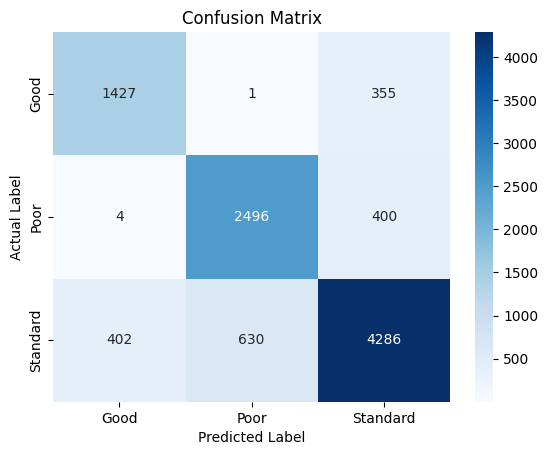

In [ ]:
# Create labels for the confusion matrix
labels = ['Good', 'Poor', 'Standard']

# Create a heatmap using seaborn
sns.heatmap(np.round(confusion_matrices / 10).astype(np.int64), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)

# Set plot title and axes labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Display the plot
plt.show()

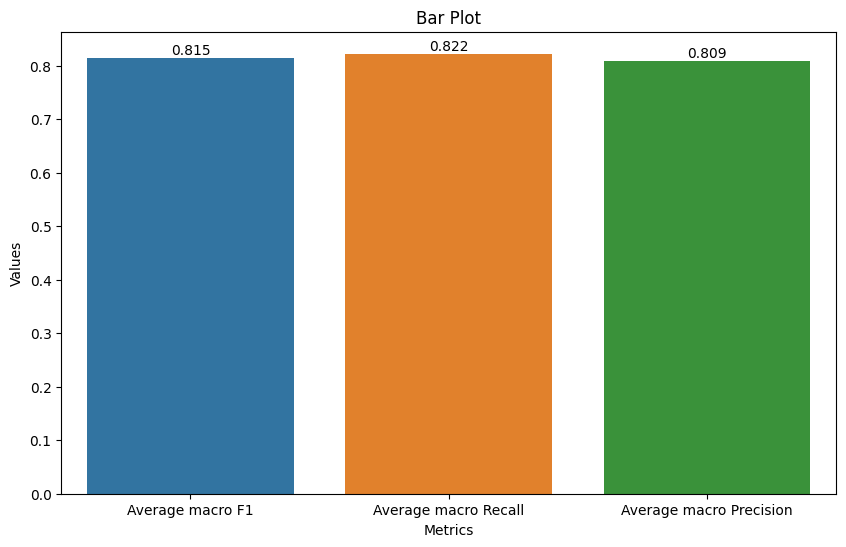

In [ ]:
# Sample data
categories = ['Average macro F1', 'Average macro Recall', 'Average macro Precision']
values = [np.mean(f1_macro), np.mean(recall_macro), np.mean(precision_macro)]

# Set the figure size
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(x=categories, y=values)

# Add numbers on top of the bars
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 3)), ha='center', va='bottom')

# Set plot title and axes labels
plt.title('Bar Plot')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Display the plot
plt.show()

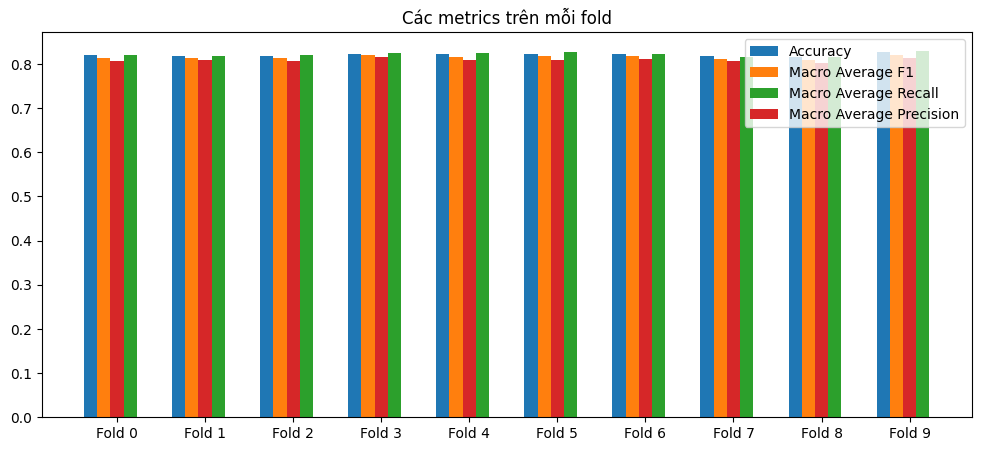

In [ ]:
plt.figure(figsize=(12,5))
X_ticks = ["Fold " + str(i) for i in range(10)]
X_axis = np.arange(len(X_ticks))
plt.bar(X_axis - 0.3, acc, 0.15, label="Accuracy", tick_label=X_ticks)
plt.bar(X_axis - 0.15, f1_macro, 0.15, label="Macro Average F1", tick_label=X_ticks)
plt.bar(X_axis + 0.15, recall_macro, 0.15, label="Macro Average Recall", tick_label=X_ticks)
plt.bar(X_axis, precision_macro, 0.15, label="Macro Average Precision", tick_label=X_ticks)
plt.title("Các metrics trên mỗi fold")
plt.legend()
plt.show()

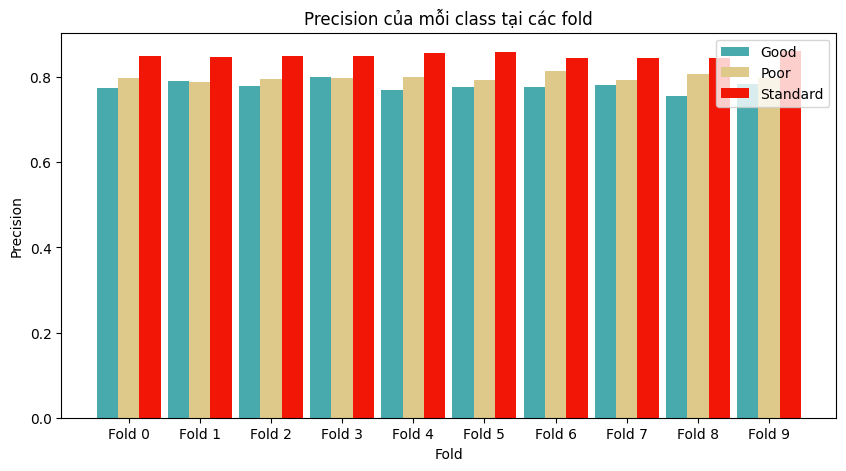

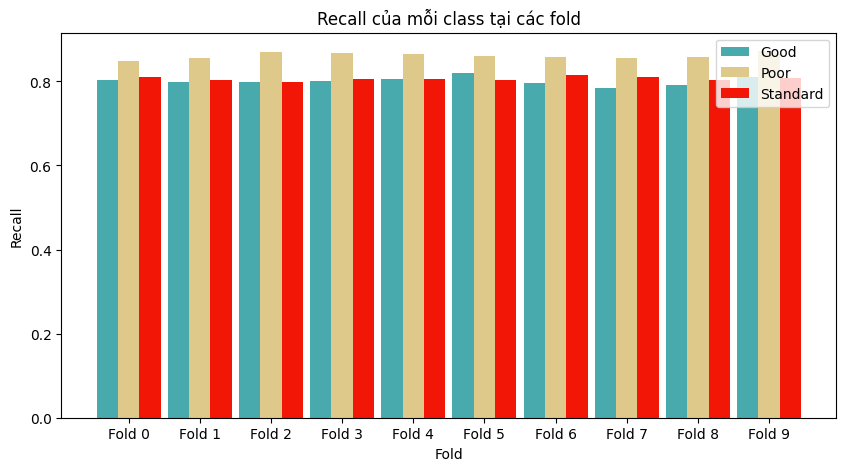

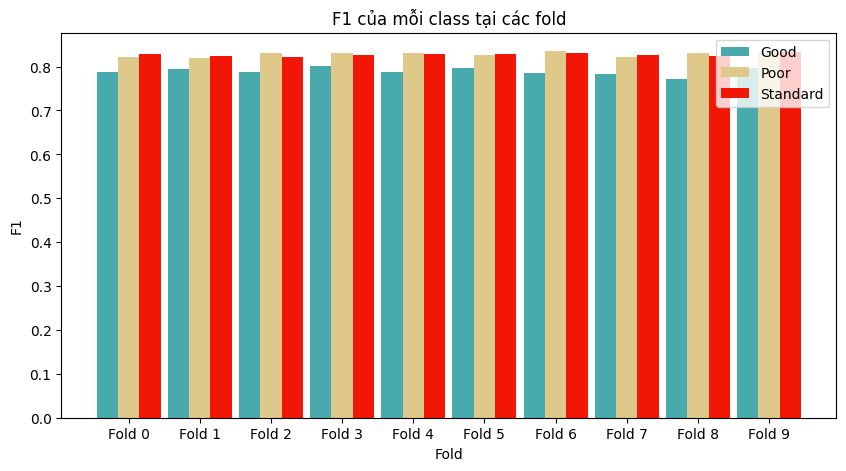

In [ ]:
metrics_dict = {
    "Precision": [],
    "Recall" : [],
    "F1": []
}

for i in range(10):
  metrics_dict["Precision"].append(metrics[i][0])
  metrics_dict["Recall"].append(metrics[i][1])
  metrics_dict["F1"].append(metrics[i][2])

metrics_dict["Precision"] = np.vstack(metrics_dict["Precision"])
metrics_dict["Recall"] = np.vstack(metrics_dict["Recall"])
metrics_dict["F1"] = np.vstack(metrics_dict["F1"])

for metric, values in metrics_dict.items():
  plt.figure(figsize=(10,5))
  plt.bar(X_axis - 0.2, values[:, 0], 0.3,
          label="Good", color="#48AAAD")
  plt.bar(X_axis + 0.1, values[:, 1], 0.3,
          label="Poor", tick_label=X_ticks, color="#DFC98A")
  plt.bar(X_axis + 0.4, values[:, 2], 0.3,
          label="Standard", color="#f21607")

  plt.title(f"{metric} của mỗi class tại các fold")
  plt.xlabel("Fold")
  plt.ylabel(f"{metric}")

  plt.legend()
  plt.show()